# Foundations of Machine learning

Problem Set 2

Emily Fu

In [49]:
# importing packages

import pandas as pd
# RandomForestRegressor
from sklearn.ensemble import RandomForestRegressor
# train_test_split, GridSearchCV, KFold
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
# ridge regression
from sklearn.linear_model import Ridge
# standard scaler
from sklearn.preprocessing import StandardScaler
# pipeline
from sklearn.pipeline import Pipeline

import numpy as np

import matplotlib.pyplot as plt

In [27]:
# import data
# california housing dataset and wine dataset
from sklearn.datasets import fetch_california_housing, load_wine
from sklearn.model_selection import train_test_split

# random seed
seed = 420

# number of folds for cross-validation
k_folds = 5

## Continuous Outcome Regression

Implement conformal inference for regression using ridge regression with penalty parameter selected via cross-validation as the model, and the conformity score: $s(x,y) = |y−\hat{f}(x)|$ where $\hat{f}(x)$ is the predicted value from the ridge regression model.

Conformal coverage theorem thing
P(Y∈C(X))>= 0.9

In [ ]:
# Split the dataset into three parts: a training set (60%) used for initial model fitting, 
# a calibration set (20%) used for conformal inference calibration, 
# and a test set (20%) used for final evaluation.
housing = fetch_california_housing()
X, y = housing['data'], housing['target']

# training vs test/calibration
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=seed, shuffle=True)

# calibration data and test data
X_cal, X_test, y_cal, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=seed, shuffle=True)

# store size of calibration set
n_cal = len(X_cal)

In [64]:
# Train your penalized linear regression model on the training set using the optimal 
# penalty found using cross-validation.

# scaling features and ridge regression with grid search
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge())])
# define possible penalties (this isn't the same as the confidence interval they just call it alpha)
param_grid = {'ridge__alpha': np.logspace(-4, 4, 50)}
# grid search with 5-fold cross-validation
grid = GridSearchCV(estimator=pipe, param_grid=param_grid, cv=k_folds)
# fit the model
grid.fit(X_train, y_train)

# For each point (xi,yi) in the calibration set, compute the conformity score s(xi,yi).
best_model = grid.best_estimator_
y_cal_pred = best_model.predict(X_cal)
conformity_scores = np.abs(y_cal - y_cal_pred)

# For a desired confidence level 1−alpha (e.g., alpha = 0.1 for 90% confidence), 
# find the (1−alpha)(n+ 1)/n-th quantile of the calibration scores, where n is the size of the calibration set.
alpha = 0.1
quantile = np.quantile(conformity_scores, (1 - alpha) * (n_cal + 1) / n_cal)


Empirical coverage on the test set: 0.887
Average interval width: 2.090


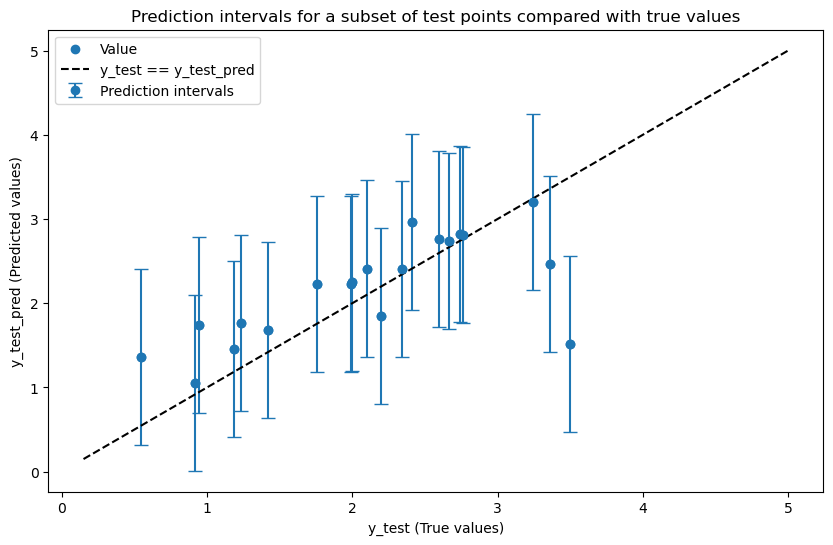

In [65]:
# For evaluation, construct prediction intervals [\hat{f}(x) - q, \hat{f}(x) + q] 
# where q is the appropriate quantile of calibration scores.
y_test_pred = best_model.predict(X_test)
lower = y_test_pred - quantile
upper = y_test_pred + quantile
# when the true value falls within the prediction set
coverage = np.mean((y_test >= lower) & (y_test <= upper))

# Compute empirical coverage on the test set, 
print(f'Empirical coverage on the test set: {coverage:.3f}')
# calculate average interval width, 
interval_widths = upper - lower
avg_interval_width = np.mean(interval_widths)
print(f'Average interval width: {avg_interval_width:.3f}')

# and plot prediction intervals for a subset of test points compared with true values.
subset_indices = np.random.choice(len(X_test), size=20, replace=False)
plt.figure(figsize=(10, 6))
plt.scatter(y_test[subset_indices], y_test_pred[subset_indices], label='Value')
plt.errorbar(y_test[subset_indices], y_test_pred[subset_indices], 
             yerr=[y_test_pred[subset_indices] - lower[subset_indices], 
                    upper[subset_indices] - y_test_pred[subset_indices]], 
             fmt='o', capsize=5, label='Prediction intervals')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', label='y_test == y_test_pred')
plt.xlabel('y_test (True values)')
plt.ylabel('y_test_pred (Predicted values)')
plt.title('Prediction intervals for a subset of test points compared with true values')
plt.legend()
plt.show()